In [3]:
from datasets import load_dataset

ds = load_dataset("alpayariyak/IAM_Sentences")

print(ds)

/home/adrian/.conda/envs/data_science_3.13/lib/python3.13/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


DatasetDict({
    train: Dataset({
        features: ['image', 'text'],
        num_rows: 5663
    })
})


# Pobranie i wygenerowanie pliku ze zbiorem danych

In [4]:
import pandas as pd

df = pd.read_parquet("hf://datasets/xReniar/IAM-Dataset/data/train-00000-of-00001.parquet")

In [ ]:
df.head()

,filename,line_id,line_text,line_bboxes,word_id,word_text,word_bboxes
0,a01-000u.png,"[a01-000u-00, a01-000u-01, a01-000u-02, a01-00...","[A MOVE to stop Mr. Gaitskell from, nominating...","[[408, 746, 2069, 834], [395, 932, 2245, 1037]...","[a01-000u-00-00, a01-000u-00-01, a01-000u-00-0...","[A, MOVE, to, stop, Mr., Gaitskell, from, nomi...","[[408, 768, 435, 819], [507, 766, 720, 814], [..."
1,a01-000x.png,"[a01-000x-00, a01-000x-01, a01-000x-02, a01-00...","[A MOVE to stop Mr. Gaitskell from nominating,...","[[375, 748, 1936, 896], [382, 924, 1977, 1072]...","[a01-000x-00-00, a01-000x-00-01, a01-000x-00-0...","[A, MOVE, to, stop, Mr., Gaitskell, from, nomi...","[[375, 767, 410, 834], [506, 763, 649, 829], [..."
2,a01-003.png,"[a01-003-00, a01-003-01, a01-003-02, a01-003-0...",[Though they may gather some Left-wing support...,"[[325, 895, 2132, 1035], [319, 1078, 2105, 120...","[a01-003-00-00, a01-003-00-01, a01-003-00-02, ...","[Though, they, may, gather, some, Left-wing, s...","[[325, 895, 529, 1027], [587, 910, 696, 1000],..."
3,a01-003u.png,"[a01-003u-00, a01-003u-01, a01-003u-02, a01-00...","[Though they may gather some Left-wing, suppor...","[[356, 800, 2295, 906], [365, 976, 2203, 1079]...","[a01-003u-00-00, a01-003u-00-01, a01-003u-00-0...","[Though, they, may, gather, some, Left-wing, s...","[[356, 822, 666, 902], [732, 824, 894, 899], [..."
4,a01-003x.png,"[a01-003x-00, a01-003x-01, a01-003x-02, a01-00...",[Though they may gather some Left-wing support...,"[[312, 875, 2107, 1042], [307, 1046, 2138, 121...","[a01-003x-00-00, a01-003x-00-01, a01-003x-00-0...","[Though, they, may, gather, some, Left-wing, s...","[[312, 895, 518, 1035], [603, 901, 725, 1029],..."


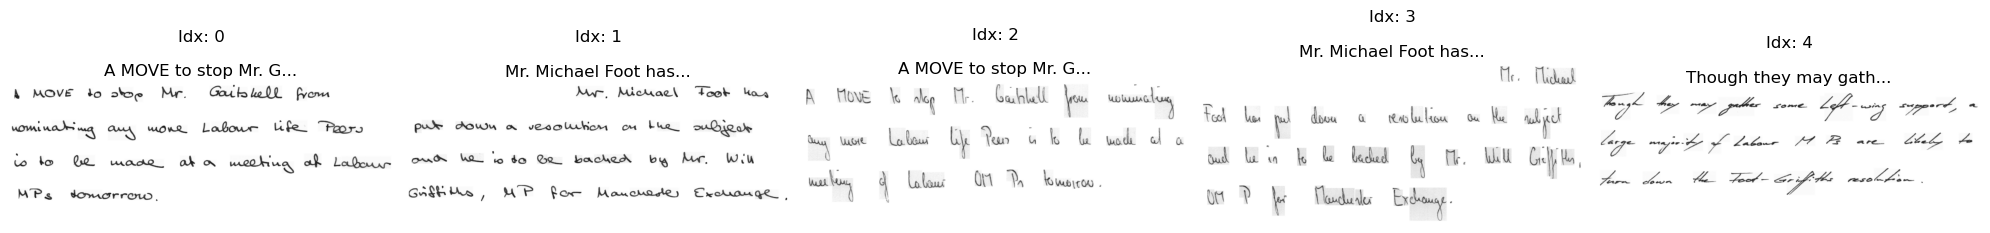

In [ ]:
import os

import matplotlib.pyplot as plt

train_ds = ds["train"]

fig, axes = plt.subplots(1, 5, figsize=(20, 4))

for i, ax in enumerate(axes):
    sample = train_ds[i]
    
    img = sample["image"]
    file_name = os.path.basename(getattr(img, "filename", "brak_nazwy"))
    print(file_name)

    ax.imshow(img)
    ax.set_title(f"Idx: {i}\n{file_name}\n{sample['text'][:20]}...")
    ax.axis("off")

plt.tight_layout()
plt.show()

In [5]:
import os
path = "dataset_forms/data"

# Pobierz tylko nazwy folderów z podanej ścieżki
folder_names = [name for name in os.listdir(path) if os.path.isdir(os.path.join(path, name))]

print(folder_names)

folder_files = {}

for folder in folder_names:
    folder_path = os.path.join(path, folder)
    files = [f for f in os.listdir(folder_path) if os.path.isfile(os.path.join(folder_path, f))]
    folder_files[folder] = files

print(f"Znaleziono pliki w {len(folder_files)} folderach.")

print(folder_files['000'])

['000', '001', '002', '003', '004', '005', '006', '007', '008', '009', '010', '011', '012', '013', '014', '015', '016', '017', '018', '019', '020', '021', '022', '023', '024', '025', '026', '027', '028', '029', '030', '031', '032', '033', '034', '035', '036', '037', '038', '039', '040', '041', '042', '043', '044', '045', '046', '047', '048', '049', '050', '051', '052', '053', '054', '055', '056', '058', '059', '060', '061', '062', '063', '064', '065', '066', '067', '068', '069', '070', '071', '072', '073', '074', '075', '076', '077', '078', '079', '080', '081', '082', '083', '084', '085', '086', '087', '088', '089', '090', '091', '092', '093', '094', '095', '096', '097', '098', '099', '100', '102', '103', '104', '105', '106', '107', '108', '109', '110', '111', '112', '113', '114', '115', '116', '117', '118', '119', '120', '121', '122', '123', '124', '125', '126', '127', '128', '129', '130', '131', '132', '133', '134', '135', '136', '137', '138', '139', '140', '141', '142', '143', '144'

In [ ]:
# Mapowanie: nazwa pliku -> klasa użytkownika (nazwa folderu)
filename_to_user_class = {
    fname: user_class
    for user_class, file_list in folder_files.items()
    for fname in file_list
}

# --- ds (zostawiamy, ale z bezpiecznym fallbackiem) ---
# def add_user_class(example):
#     img = example["image"]
#     fname = os.path.basename(getattr(img, "filename", "") or "")
#     return {"user_class": filename_to_user_class.get(fname)}

# ds["train"] = ds["train"].map(add_user_class)
# missing_ds = sum(v is None for v in ds["train"]["user_class"])
# print(f"[ds] Brak przypisanej klasy dla {missing_ds} rekordów.")

# --- df (to samo, ale po kolumnie filename) ---
df["user_class"] = df["filename"].apply(
    lambda x: filename_to_user_class.get(os.path.basename(str(x)))
)

missing_df = df["user_class"].isna().sum()

print(f"[df] Brak przypisanej klasy dla {missing_df} rekordów.")


[df] Brak przypisanej klasy dla 0 rekordów.


,filename,line_id,line_text,line_bboxes,word_id,word_text,word_bboxes,user_class
0,a01-000u.png,"[a01-000u-00, a01-000u-01, a01-000u-02, a01-00...","[A MOVE to stop Mr. Gaitskell from, nominating...","[[408, 746, 2069, 834], [395, 932, 2245, 1037]...","[a01-000u-00-00, a01-000u-00-01, a01-000u-00-0...","[A, MOVE, to, stop, Mr., Gaitskell, from, nomi...","[[408, 768, 435, 819], [507, 766, 720, 814], [...",000
1,a01-000x.png,"[a01-000x-00, a01-000x-01, a01-000x-02, a01-00...","[A MOVE to stop Mr. Gaitskell from nominating,...","[[375, 748, 1936, 896], [382, 924, 1977, 1072]...","[a01-000x-00-00, a01-000x-00-01, a01-000x-00-0...","[A, MOVE, to, stop, Mr., Gaitskell, from, nomi...","[[375, 767, 410, 834], [506, 763, 649, 829], [...",001
2,a01-003.png,"[a01-003-00, a01-003-01, a01-003-02, a01-003-0...",[Though they may gather some Left-wing support...,"[[325, 895, 2132, 1035], [319, 1078, 2105, 120...","[a01-003-00-00, a01-003-00-01, a01-003-00-02, ...","[Though, they, may, gather, some, Left-wing, s...","[[325, 895, 529, 1027], [587, 910, 696, 1000],...",002
3,a01-003u.png,"[a01-003u-00, a01-003u-01, a01-003u-02, a01-00...","[Though they may gather some Left-wing, suppor...","[[356, 800, 2295, 906], [365, 976, 2203, 1079]...","[a01-003u-00-00, a01-003u-00-01, a01-003u-00-0...","[Though, they, may, gather, some, Left-wing, s...","[[356, 822, 666, 902], [732, 824, 894, 899], [...",000
4,a01-003x.png,"[a01-003x-00, a01-003x-01, a01-003x-02, a01-00...",[Though they may gather some Left-wing support...,"[[312, 875, 2107, 1042], [307, 1046, 2138, 121...","[a01-003x-00-00, a01-003x-00-01, a01-003x-00-0...","[Though, they, may, gather, some, Left-wing, s...","[[312, 895, 518, 1035], [603, 901, 725, 1029],...",003


In [ ]:
df.head()

,filename,line_id,line_text,line_bboxes,word_id,word_text,word_bboxes,user_class
0,a01-000u.png,"[a01-000u-00, a01-000u-01, a01-000u-02, a01-00...","[A MOVE to stop Mr. Gaitskell from, nominating...","[[408, 746, 2069, 834], [395, 932, 2245, 1037]...","[a01-000u-00-00, a01-000u-00-01, a01-000u-00-0...","[A, MOVE, to, stop, Mr., Gaitskell, from, nomi...","[[408, 768, 435, 819], [507, 766, 720, 814], [...",000
1,a01-000x.png,"[a01-000x-00, a01-000x-01, a01-000x-02, a01-00...","[A MOVE to stop Mr. Gaitskell from nominating,...","[[375, 748, 1936, 896], [382, 924, 1977, 1072]...","[a01-000x-00-00, a01-000x-00-01, a01-000x-00-0...","[A, MOVE, to, stop, Mr., Gaitskell, from, nomi...","[[375, 767, 410, 834], [506, 763, 649, 829], [...",001
2,a01-003.png,"[a01-003-00, a01-003-01, a01-003-02, a01-003-0...",[Though they may gather some Left-wing support...,"[[325, 895, 2132, 1035], [319, 1078, 2105, 120...","[a01-003-00-00, a01-003-00-01, a01-003-00-02, ...","[Though, they, may, gather, some, Left-wing, s...","[[325, 895, 529, 1027], [587, 910, 696, 1000],...",002
3,a01-003u.png,"[a01-003u-00, a01-003u-01, a01-003u-02, a01-00...","[Though they may gather some Left-wing, suppor...","[[356, 800, 2295, 906], [365, 976, 2203, 1079]...","[a01-003u-00-00, a01-003u-00-01, a01-003u-00-0...","[Though, they, may, gather, some, Left-wing, s...","[[356, 822, 666, 902], [732, 824, 894, 899], [...",000
4,a01-003x.png,"[a01-003x-00, a01-003x-01, a01-003x-02, a01-00...",[Though they may gather some Left-wing support...,"[[312, 875, 2107, 1042], [307, 1046, 2138, 121...","[a01-003x-00-00, a01-003x-00-01, a01-003x-00-0...","[Though, they, may, gather, some, Left-wing, s...","[[312, 895, 518, 1035], [603, 901, 725, 1029],...",003


In [ ]:
df.to_parquet("df.parquet", index=False)

# Wczytanie zbioru z pliku

In [ ]:
import pandas as pd

df = pd.read_parquet("df.parquet")

       filename                                            line_id  \
0  a01-000u.png  [a01-000u-00, a01-000u-01, a01-000u-02, a01-00...   
1  a01-000x.png  [a01-000x-00, a01-000x-01, a01-000x-02, a01-00...   
2   a01-003.png  [a01-003-00, a01-003-01, a01-003-02, a01-003-0...   
3  a01-003u.png  [a01-003u-00, a01-003u-01, a01-003u-02, a01-00...   
4  a01-003x.png  [a01-003x-00, a01-003x-01, a01-003x-02, a01-00...   

                                           line_text  \
0  [A MOVE to stop Mr. Gaitskell from, nominating...   
1  [A MOVE to stop Mr. Gaitskell from nominating,...   
2  [Though they may gather some Left-wing support...   
3  [Though they may gather some Left-wing, suppor...   
4  [Though they may gather some Left-wing support...   

                                         line_bboxes  \
0  [[408, 746, 2069, 834], [395, 932, 2245, 1037]...   
1  [[375, 748, 1936, 896], [382, 924, 1977, 1072]...   
2  [[325, 895, 2132, 1035], [319, 1078, 2105, 120...   
3  [[356, 800, 229

# Rozmiar zdjęć

## Na podstawie zbioru danych

       filename user_class         word_id word_text             word_bboxes  \
0  a01-000u.png        000  a01-000u-00-00         A    [408, 768, 435, 819]   
1  a01-000u.png        000  a01-000u-00-01      MOVE    [507, 766, 720, 814]   
2  a01-000u.png        000  a01-000u-00-02        to    [796, 764, 866, 814]   
3  a01-000u.png        000  a01-000u-00-03      stop   [919, 756, 1085, 834]   
4  a01-000u.png        000  a01-000u-00-04       Mr.  [1185, 754, 1311, 815]   

                        flat_bbox  
0    [408.0, 768.0, 435.0, 819.0]  
1    [507.0, 766.0, 720.0, 814.0]  
2    [796.0, 764.0, 866.0, 814.0]  
3   [919.0, 756.0, 1085.0, 834.0]  
4  [1185.0, 754.0, 1311.0, 815.0]  
       filename user_class         word_id word_text             word_bboxes  \
0  a01-000u.png        000  a01-000u-00-00         A    [408, 768, 435, 819]   
1  a01-000u.png        000  a01-000u-00-01      MOVE    [507, 766, 720, 814]   
2  a01-000u.png        000  a01-000u-00-02        to    [796, 7

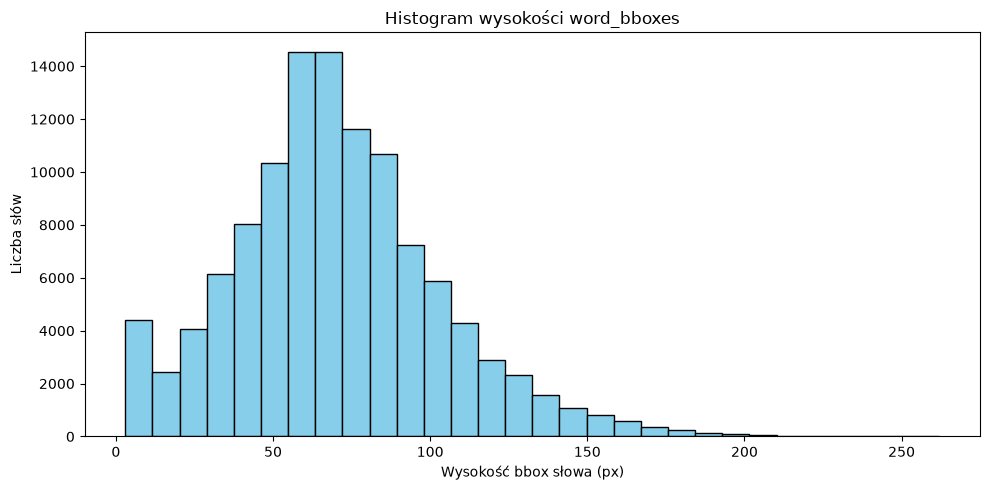

   Percentyl  Wysokość (px)
0         10           29.0
1         25           50.0
2         50           68.0
3         75           89.0
4         90          113.0


,filename,user_class,word_id,word_text,word_bboxes,x1,y1,x2,y2,bbox_width,bbox_height,bbox_area
0,a01-000u.png,000,a01-000u-00-00,A,"[408, 768, 435, 819]",408.0,768.0,435.0,819.0,27.0,51.0,1377.0
1,a01-000u.png,000,a01-000u-00-01,MOVE,"[507, 766, 720, 814]",507.0,766.0,720.0,814.0,213.0,48.0,10224.0
2,a01-000u.png,000,a01-000u-00-02,to,"[796, 764, 866, 814]",796.0,764.0,866.0,814.0,70.0,50.0,3500.0
3,a01-000u.png,000,a01-000u-00-03,stop,"[919, 756, 1085, 834]",919.0,756.0,1085.0,834.0,166.0,78.0,12948.0
4,a01-000u.png,000,a01-000u-00-04,Mr.,"[1185, 754, 1311, 815]",1185.0,754.0,1311.0,815.0,126.0,61.0,7686.0


In [20]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# Rozgrupowanie słów do osobnych wierszy i analiza word_bboxes

df_words = (
    df[["filename", "user_class", "word_id", "word_text", "word_bboxes"]]
    .explode(["word_id", "word_text", "word_bboxes"], ignore_index=True)
)

# Po powyższym explode w tej wersji danych każdy rekord word_bboxes to pojedynczy bbox (np. ndarray(4,)).
df_words = df_words[df_words["word_bboxes"].notna()].copy()

def to_flat_bbox(x):
    if isinstance(x, np.ndarray):
        if x.ndim == 1 and x.shape[0] == 4:
            return x.astype(float).tolist()
        return None
    if isinstance(x, (list, tuple)) and len(x) == 4 and all(np.isscalar(v) for v in x):
        return [float(v) for v in x]
    return None

df_words["flat_bbox"] = df_words["word_bboxes"].apply(to_flat_bbox)
df_words = df_words[df_words["flat_bbox"].notna()].copy()
print(df_words.head())

if df_words.empty:
    raise ValueError("Brak poprawnych word_bboxes po filtracji.")

# Współrzędne bboxów
coords = pd.DataFrame(
    df_words["flat_bbox"].tolist(),
    columns=["x1", "y1", "x2", "y2"],
    index=df_words.index,
)
df_words[["x1", "y1", "x2", "y2"]] = coords
df_words.drop(columns=["flat_bbox"], inplace=True)

df_words["bbox_width"] = df_words["x2"] - df_words["x1"]
df_words["bbox_height"] = df_words["y2"] - df_words["y1"]
df_words["bbox_area"] = df_words["bbox_width"] * df_words["bbox_height"]

bbox_heights = df_words["bbox_height"].tolist()

print(df_words.head())
print(f"Znaleziono {len(bbox_heights)} słów.")
print(f"Min. wysokość bbox: {min(bbox_heights)} px")
print(f"Maks. wysokość bbox: {max(bbox_heights)} px")
print(f"Średnia wysokość bbox: {np.mean(bbox_heights):.1f} px")
print(f"Mediana wysokości bbox: {np.median(bbox_heights):.1f} px")
print(f"Odchylenie standardowe: {np.std(bbox_heights):.1f} px")

plt.figure(figsize=(10, 5))
plt.hist(bbox_heights, bins=30, color="skyblue", edgecolor="black")
plt.xlabel("Wysokość bbox słowa (px)")
plt.ylabel("Liczba słów")
plt.title("Histogram wysokości word_bboxes")
plt.tight_layout()
plt.show()

percentiles = [10, 25, 50, 75, 90]
stats_df = pd.DataFrame({
    "Percentyl": percentiles,
    "Wysokość (px)": [np.percentile(bbox_heights, p) for p in percentiles]
})

print(stats_df)
df_words.head()

## Na podstawie zdjęć

In [ ]:
from pathlib import Path
import cv2
import matplotlib.pyplot as plt

img_dir = Path("dataset_words/words")
image_extensions = {".png", ".jpg", ".jpeg", ".bmp", ".gif", ".tif", ".tiff"}

image_paths = [p for p in img_dir.rglob("*") if p.is_file() and p.suffix.lower() in image_extensions]

if not image_paths:
    raise FileNotFoundError(f"Nie znaleziono obrazów w katalogu: {img_dir}")

image_heights = []
for path in image_paths:
    img = cv2.imread(str(path))
    if img is not None:
        image_heights.append(img.shape[0])

Znaleziono 115318 obrazów.
Min. wysokość: 1 px
Maks. wysokość: 342 px
Średnia wysokość: 70.0 px
Mediana wysokości: 68.0 px
Odchylenie standardowe: 33.2 px
Wariancja: 1102.3 px²
Rozstęp: 341 px


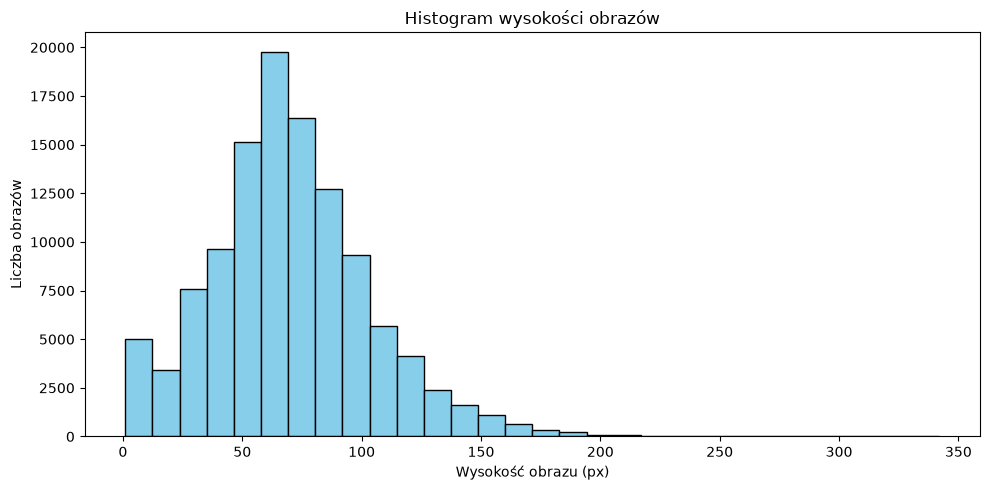

   Percentyl  Wysokość (px)
0         10           29.0
1         25           49.0
2         50           68.0
3         75           88.0
4         90          113.0
     Wysokość (px)  Liczba obrazów
0                1             132
1                3              34
2                4             167
3                5             487
4                6             795
..             ...             ...
245            292               1
246            303               1
247            304               2
248            308               1
249            342               1

[250 rows x 2 columns]


In [ ]:
import numpy as np
import pandas as pd

# STATYSTYKI

if not image_heights:
    raise ValueError("Brak danych o wysokościach obrazów.")

print(f"Znaleziono {len(image_heights)} obrazów.")
print(f"Min. wysokość: {min(image_heights)} px")
print(f"Maks. wysokość: {max(image_heights)} px")
print(f"Średnia wysokość: {sum(image_heights) / len(image_heights):.1f} px")
print(f"Mediana wysokości: {np.median(image_heights):.1f} px")
print(f"Odchylenie standardowe: {np.std(image_heights):.1f} px")
print(f"Wariancja: {np.var(image_heights):.1f} px²")
print(f"Rozstęp: {max(image_heights) - min(image_heights)} px")

# HISTOGRAM

plt.figure(figsize=(10, 5))
plt.hist(image_heights, bins=30, color="skyblue", edgecolor="black")
plt.xlabel("Wysokość obrazu (px)")
plt.ylabel("Liczba obrazów")
plt.title("Histogram wysokości obrazów")
plt.tight_layout()
plt.show()

# PERCENTYLE

heights_array = np.array(image_heights)
percentiles = [10, 25, 50, 75, 90]
stats = {
    'Percentyl': percentiles,
    'Wysokość (px)': [np.percentile(heights_array, p) for p in percentiles]
}

stats_df = pd.DataFrame(stats)
print(stats_df)

# Utwórz tabelę ze wszystkimi wysokościami i ich liczebności
height_counts = pd.DataFrame({
    'Wysokość (px)': sorted(set(image_heights)),
    'Liczba obrazów': [image_heights.count(h) for h in sorted(set(image_heights))]
})

print(height_counts)

# Zbalansowanie klas

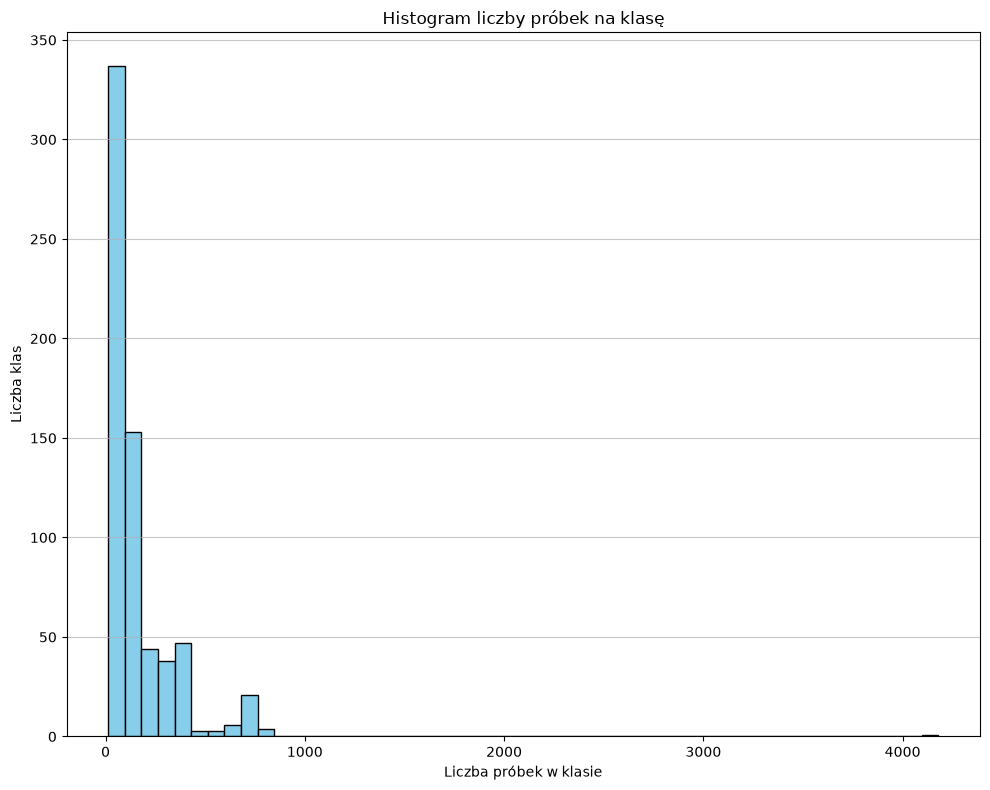

Liczba klas: 657
Min. próbek w klasie: 13
Max. próbek w klasie: 4180
Średnia próbek na klasę: 174.3
Mediana próbek na klasę: 91.0
Odchylenie standardowe: 221.8

Top 5 klas z największą liczbą próbek:
user_class
611    13
633    29
669    30
099    42
307    43
Name: count, dtype: int64

Top 5 klas z najmniejszą liczbą próbek:
user_class
671     782
552     790
588     827
551     833
000    4180
Name: count, dtype: int64
Percentyle liczby próbek na klasę:
   Percentyl  Liczba próbek
0         10           63.0
1         25           72.0
2         50           91.0
3         75          187.0
4         90          366.4


In [46]:
# Histogram: ile klas posiada daną liczbę próbek
import common

df_words = build_word_dataframe(df, pics_path="dataset_words/words")

counts_per_class = df_words["user_class"].value_counts().sort_values(ascending=True)
# counts_per_class = df_words["user_class"].value_counts().sort_values(ascending=True).where(lambda x: x < 3000).dropna()


plt.figure(figsize=(10, 8))
plt.hist(counts_per_class, bins=50, color="skyblue", edgecolor="black")
plt.xlabel("Liczba próbek w klasie")
plt.ylabel("Liczba klas")
plt.title("Histogram liczby próbek na klasę")
plt.grid(axis="y", alpha=0.7)
plt.tight_layout()
plt.show()

# Statystyki dotyczące liczby próbek na klasę
print(f"Liczba klas: {len(counts_per_class)}")
print(f"Min. próbek w klasie: {counts_per_class.min()}")
print(f"Max. próbek w klasie: {counts_per_class.max()}")
print(f"Średnia próbek na klasę: {counts_per_class.mean():.1f}")
print(f"Mediana próbek na klasę: {counts_per_class.median():.1f}")
print(f"Odchylenie standardowe: {counts_per_class.std():.1f}")

# Klasy z najmniejszą i największą liczbą próbek
print(f"\nTop 5 klas z największą liczbą próbek:")
print(counts_per_class.head())
print(f"\nTop 5 klas z najmniejszą liczbą próbek:")
print(counts_per_class.tail())


# Percentyle dla liczby próbek na klasę
percentiles_classes = [10, 25, 50, 75, 90]
percentile_values = [np.percentile(counts_per_class, p) for p in percentiles_classes]

percentile_df = pd.DataFrame({
    'Percentyl': percentiles_classes,
    'Liczba próbek': percentile_values
})

print("Percentyle liczby próbek na klasę:")
print(percentile_df)